### Part A - Data Analysis & Testing Tasks:

#### 1. What is Statistical Distribution?
A statistical distribution describes how the values of a variable are spread across different possible outcomes. It shows the pattern of variation in the data and helps us understand how frequently certain values occur. By studying distributions, we can summarize data behavior and make predictions or decisions based on probability.

---

#### 2. What is a Q-Q Plot and Why is it Used?
A Q-Q (Quantile-Quantile) plot is a graphical method used to check whether a dataset follows a particular theoretical distribution, most commonly the normal distribution. It compares the quantiles of the sample data with the quantiles of the reference distribution. If the points lie approximately on a straight line, the data is likely to follow that distribution.

---

#### 3. Difference Between Discrete and Continuous Distributions
Discrete distributions deal with countable outcomes such as the number of transactions or number of successes. These values are usually whole numbers. Continuous distributions, on the other hand, deal with measurable quantities such as transaction amount, height, or time, which can take any value within a given range. Discrete distributions use probability mass functions, while continuous distributions use probability density functions.

---

#### 4. What is Bernoulli Distribution?
The Bernoulli distribution models an experiment with only two possible outcomes: success (1) or failure (0). It is defined by a single parameter, p, which represents the probability of success. This distribution is commonly used when analyzing binary events such as whether a transaction is successful or not.

---

#### 5. What is Binomial Distribution?
The Binomial distribution represents the number of successes in a fixed number of independent Bernoulli trials. It depends on two parameters: n (number of trials) and p (probability of success in each trial). It is useful when we want to count how many successes occur over multiple attempts, such as successful transactions in a week.

---

#### 6. Explain Log-Normal Distribution
A variable follows a Log-Normal distribution if the logarithm of the variable is normally distributed. This distribution is positively skewed, meaning most values are small and a few values are very large. It is commonly used to model financial data like transaction amounts or income, where extreme high values can occur but are rare.

---

#### 7. Explain Power Law Distribution
Power Law distribution describes situations where small values occur very frequently and large values occur rarely but with significant impact. It has a heavy tail, meaning extreme events have a higher probability compared to normal distribution. It is often observed in financial markets, social networks, and natural phenomena.

---

#### 8. What is Box-Cox Transform?
Box-Cox transformation is a mathematical technique used to make skewed data more symmetric and closer to normal distribution. It helps stabilize variance and improve the performance of statistical models. The transformation uses a parameter called lambda (λ), which determines the strength of transformation applied to the data.

---

#### 9. Explain Poisson Distribution with an Example
Poisson distribution is used to model the number of events occurring within a fixed interval of time or space. It is defined by a single parameter, λ (lambda), which represents the average number of events. For example, the number of transactions occurring per day in a system can often be modeled using Poisson distribution.

---

#### 10. What is Z-score Probability?
A Z-score measures how many standard deviations a value is away from the mean of a distribution. It is used in normal distribution to calculate probabilities of extreme or unusual values. By converting a value into a Z-score, we can determine the probability of observing that value or something more extreme.

---

#### 11. Difference Between Probability Density Function (PDF) and Cumulative Distribution Function (CDF)
A Probability Density Function (PDF) describes the shape of a continuous distribution and shows how dense the probability is around different values. The total area under the PDF curve equals 1. A Cumulative Distribution Function (CDF) gives the probability that a variable is less than or equal to a specific value. While PDF explains distribution shape, CDF helps in finding cumulative probabilities.

### Part B - Data Analysis & Testing Tasks:

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import bernoulli, binom, poisson, lognorm, powerlaw, norm

In [4]:
data = pd.read_excel("spread_locator_dataset - spread_locator_dataset.xlsx")
data["transaction_date"] = pd.to_datetime(data["transaction_date"])

Probability of Success: 0.44545454545454544


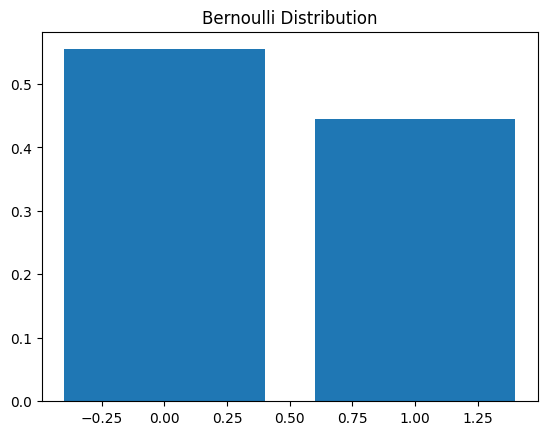

Average Weekly Transactions (n): 36


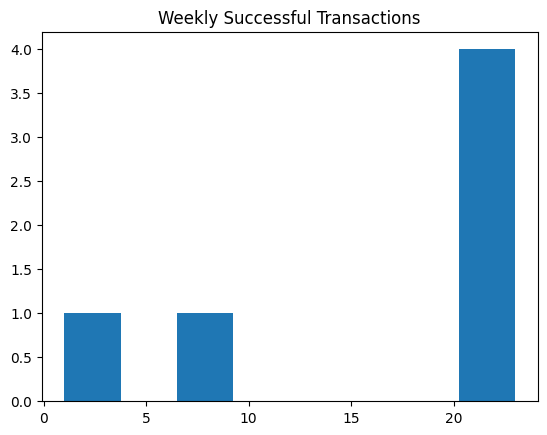

In [5]:
# 1. BERNOULLI & BINOMIAL

# Bernoulli
data["success"] = np.where(data["transaction_status"] == "Success", 1, 0)
p = data["success"].mean()
print("Probability of Success:", p)

# Plot Bernoulli
plt.bar([0,1], [1-p, p])
plt.title("Bernoulli Distribution")
plt.show()

# Binomial
data["week"] = data["transaction_date"].dt.isocalendar().week
weekly_success = data.groupby("week")["success"].sum()

n = int(data.groupby("week").size().mean())
print("Average Weekly Transactions (n):", n)

# Plot Binomial
plt.hist(weekly_success, bins=8)
plt.title("Weekly Successful Transactions")
plt.show()

Daily Average Transactions (Lambda): 7.096774193548387


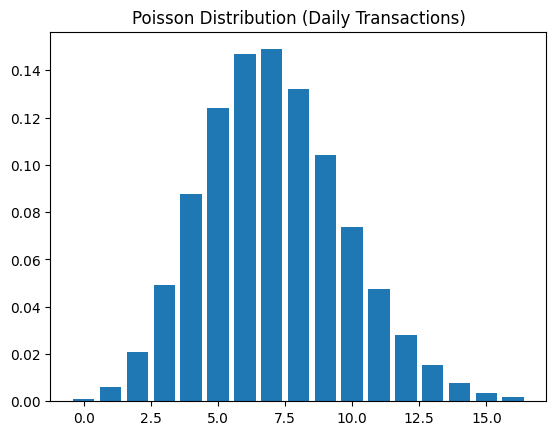

In [6]:
# 2. POISSON (transactions per day)

daily = data.groupby(data["transaction_date"].dt.date).size()
lam = daily.mean()

print("Daily Average Transactions (Lambda):", lam)

x = np.arange(0, max(daily)+5)
y = poisson.pmf(x, lam)

plt.bar(x, y)
plt.title("Poisson Distribution (Daily Transactions)")
plt.show()

Log-normal shape: 0.4749178350151927
Power law alpha: 0.41232325172331613


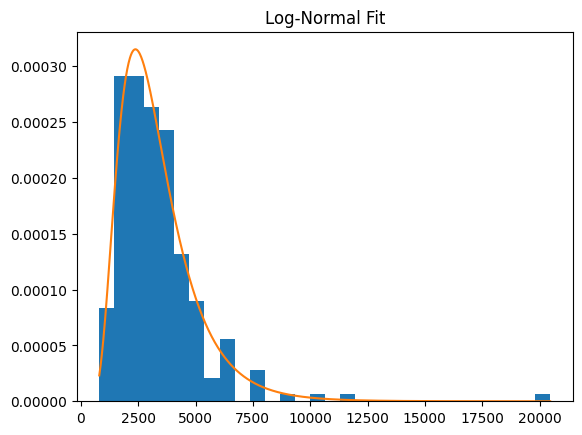

In [7]:
# 3. LOG-NORMAL & POWER LAW

amount = data["transaction_amount"]

# Log-normal
shape, loc, scale = lognorm.fit(amount, floc=0)
print("Log-normal shape:", shape)

# Power law
alpha, loc2, scale2 = powerlaw.fit(amount)
print("Power law alpha:", alpha)

# Plot Log-normal fit
x_vals = np.linspace(amount.min(), amount.max(), 1000)
pdf_lognorm = lognorm.pdf(x_vals, shape, loc, scale)

plt.hist(amount, bins=30, density=True)
plt.plot(x_vals, pdf_lognorm)
plt.title("Log-Normal Fit")
plt.show()

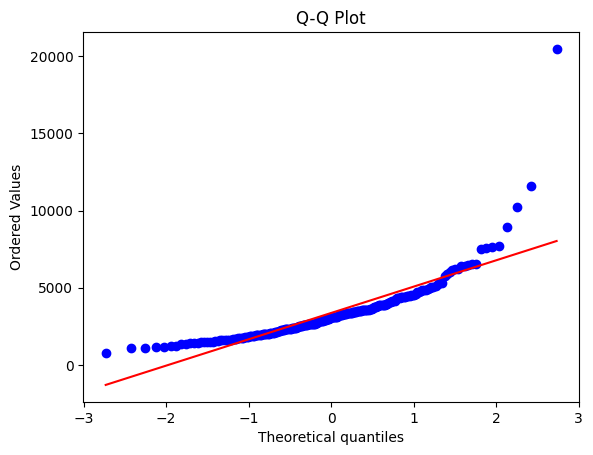

In [10]:
# 4. Q-Q PLOT

stats.probplot(amount, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

Box-Cox Lambda: -0.18083390743966327


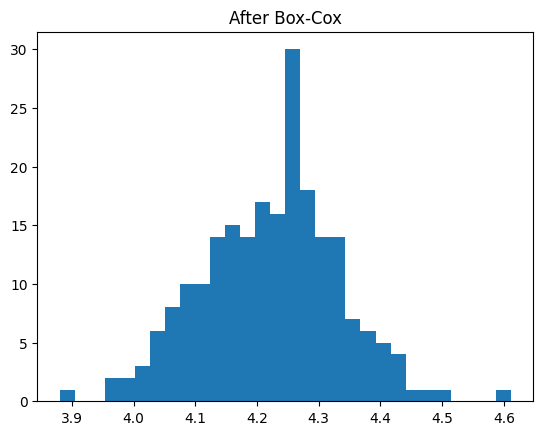

In [11]:
# 5. BOX-COX TRANSFORM

transformed, lam_box = stats.boxcox(amount)
print("Box-Cox Lambda:", lam_box)

plt.hist(transformed, bins=30)
plt.title("After Box-Cox")
plt.show()

In [13]:
# 6. Z-SCORE & PROBABILITY > 5000

mean_val = amount.mean()
std_val = amount.std()

z = (5000 - mean_val) / std_val
prob = 1 - norm.cdf(5000, mean_val, std_val)

print("Z-score for 5000:", z)
print("Probability > 5000:", prob)

Z-score for 5000: 0.8232880785671723
Probability > 5000: 0.20517209567554384


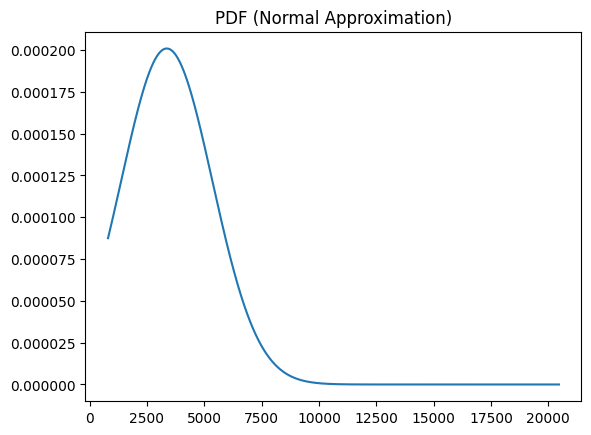

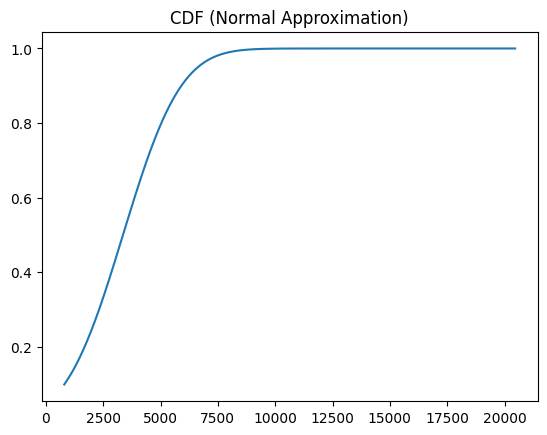

In [14]:
# 7. PDF & CDF

pdf = norm.pdf(x_vals, mean_val, std_val)
cdf = norm.cdf(x_vals, mean_val, std_val)

plt.plot(x_vals, pdf)
plt.title("PDF (Normal Approximation)")
plt.show()

plt.plot(x_vals, cdf)
plt.title("CDF (Normal Approximation)")
plt.show()

#### 8. OVERALL BEST FIT DISTRIBUTION

The overall dataset is best modeled using a mixture of distributions. However, the dominant financial variable (transaction_amount) best fits a Log-Normal distribution.

Financial transaction data usually has many small values and few very large values, creating right-skewness. This behavior is characteristic of Log-Normal distribution.